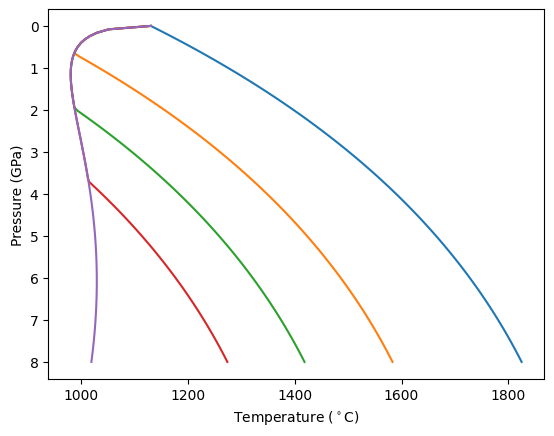

AttributeError: 'list' object has no attribute 'F'

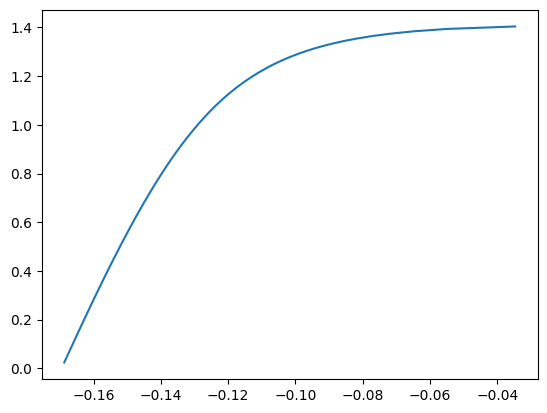

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import pyMelt as m
lz = m.lithologies.matthews.klb1()
h2o = np.array([0.1, 0.2, 0.3, 1.0])
p = np.linspace(0, 8, 100)
tsol = np.zeros([np.shape(h2o)[0]+1, np.shape(p)[0]])

tsol[0, :] = lz.TSolidus(p)

for i in range(len(h2o)):
    hlz = m.hydrousLithology(lz, h2o[i])
    for j in range(len(p)):
        tsol[i+1, j] = hlz.TSolidus(p[j])
f,a = plt.subplots(dpi=100)

for i in range(np.shape(tsol)[0]):
    a.plot(tsol[i, :], p)

a.invert_yaxis()

a.set_ylabel('Pressure (GPa)')

a.set_xlabel('Temperature ($^\circ$C)')

plt.show()
h2o = np.array([0.05, 0.1, 0.15])
cols = []
Tp = 1300.0

mantle = m.mantle([lz], [1.0], ['lz'])
dry = mantle.adiabaticMelt(Tp, dP=-0.01)

dry_dTdF = np.zeros(len(dry.T))
dry_dTdP = np.zeros(len(dry.T))

for j in range(len(dry.T)):
    dry_dTdF[j] = lz.dTdF(dry.P[j], dry.T[j])
    dry_dTdP[j] = lz.dTdP(dry.P[j], dry.T[j])

dTdF = []
dTdP = []

for i in range(len(h2o)):
    hlz = m.hydrousLithology(lz, h2o[i])
    mantle = m.mantle([hlz], [1.0], ['lz'])
    cols.append(mantle.adiabaticMelt(Tp, dP=-0.01))

    wet_dTdF = np.zeros(len(cols[i].T))
    wet_dTdP = np.zeros(len(cols[i].T))

    for j in range(len(cols[i].T)):
        wet_dTdF[j] = hlz.dTdF(cols[i].P[j], cols[i].T[j])
        wet_dTdP[j] = hlz.dTdP(cols[i].P[j], cols[i].T[j])

    dTdF.append(wet_dTdF)
    dTdP.append(wet_dTdP)
f, a = plt.subplots(dpi=100)

a.plot(-(np.array(dry.F[:-1]) - np.array(dry.F[1:]))/(dry.P[2]-dry.P[1]), dry.P[:-1], label='Dry')

for i in range(len(h2o)):
    a.plot(-(np.array(cols[i].F[:-1]) - np.array(cols.F[1:]))/(cols.P[2]-cols[i].P[1]),
           cols[i].P[:-1],
           label='{:.2f} wt% H$_2$O'.format(h2o[i]))


a.legend()

a.set_ylabel('Pressure (GPa)')
a.set_xlabel(r'$\frac{dF}{dP}$ (GPa$^{-1}$)')

a.set_title('$T_p = 1300^\circ$C')

a.invert_yaxis()

plt.show()    